# Improved Replication Experiments

Notebook ini mengembangkan replication yang sudah dikoreksi dan membandingkannya dengan hasil paper. Eksperimen mencakup corrected baseline, repeated stratified cross-validation, hyperparameter tuning, perbandingan 10 fitur versus seluruh fitur klinis, class-weight, optional SMOTE, threshold tuning, serta evaluasi terhadap nilai Table 12 paper.

Test set hanya digunakan pada evaluasi akhir. Semua imputer, encoder, scaler, resampling, dan model di-fit di dalam pipeline pada data training/fold masing-masing.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path(".\heart+disease")
FILE_NAMES = ["processed.cleveland.data", "processed.hungarian.data", "processed.switzerland.data", "processed.va.data"]
FEATURE_NAMES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
frames = []
for file_name in FILE_NAMES:
    frame = pd.read_csv(DATA_DIR / file_name, header=None, names=FEATURE_NAMES, na_values="?")
    frame[FEATURE_NAMES] = frame[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
    frames.append(frame)
df = pd.concat(frames, ignore_index=True)
df["target"] = (df["target"] > 0).astype(int)

PAPER_FEATURES = ["sex", "age", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"]
ALL_FEATURES = [feature for feature in FEATURE_NAMES if feature != "target"]
NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
X = df[ALL_FEATURES].copy()
y = df["target"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

print(f"Dataset: {len(df)} observasi")
print(f"Target distribution: {y.value_counts(normalize=True).sort_index().round(3).to_dict()}")
print(f"Train/test: {len(X_train)}/{len(X_test)}")
print(f"Paper features: {len(PAPER_FEATURES)} | all available clinical features: {len(ALL_FEATURES)}")

Dataset: 920 observasi
Target distribution: {0: 0.447, 1: 0.553}
Train/test: 644/276
Paper features: 10 | all available clinical features: 13


## 1. Evaluasi imbalance kelas

Distribusi kelas diperiksa terlebih dahulu. Karena ketidakseimbangan pada dataset ini ringan, eksperimen akan membandingkan baseline tanpa penanganan imbalance dengan `class_weight="balanced"`, bukan langsung mengasumsikan SMOTE pasti diperlukan.

In [2]:
class_distribution = y.value_counts().rename_axis("class").to_frame("count")
class_distribution["percentage"] = class_distribution["count"] / len(y) * 100
display(class_distribution)
imbalance_ratio = class_distribution["count"].max() / class_distribution["count"].min()
print(f"Imbalance ratio: {imbalance_ratio:.3f}")
print("Interpretasi: ratio dekat 1 berarti imbalance ringan; tetap gunakan stratification dan metrik per kelas.")

,count,percentage
class,,
1,509,55.326087
0,411,44.673913


Imbalance ratio: 1.238
Interpretasi: ratio dekat 1 berarti imbalance ringan; tetap gunakan stratification dan metrik per kelas.


## 2. Pipeline corrected dan baseline cross-validation

Preprocessing di-fit hanya pada training fold. Baseline ini menjadi pembanding sebelum tuning.

In [11]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"}

def make_preprocessor(features):
    numeric = [feature for feature in NUMERIC_FEATURES if feature in features]
    categorical = [feature for feature in CATEGORICAL_FEATURES if feature in features]
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("numeric", numeric_pipe, numeric), ("categorical", categorical_pipe, categorical)], remainder="drop")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    xgb = None
    XGB_AVAILABLE = False

try:
    from sklearn_lvq import GlvqModel
    LVQ_AVAILABLE = True
except Exception:
    GlvqModel = None
    LVQ_AVAILABLE = False

baseline_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", n_estimators=200, random_state=42, n_jobs=1) if XGB_AVAILABLE else None,
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "RBF (approximation)": SVC(kernel="rbf", probability=True, random_state=42),
    "LVQ (approximation/conditional)": GlvqModel(random_state=42) if LVQ_AVAILABLE else None,
}

def evaluate_cv_models(models, features, label):
    rows = []
    for name, model in models.items():
        if model is None:
            rows.append({"Experiment": label, "Model": name, **{f"{metric}_mean": np.nan for metric in scoring}, **{f"{metric}_std": np.nan for metric in scoring}, "Status": "unavailable"})
            continue
        pipe = Pipeline([("preprocessor", make_preprocessor(features)), ("model", model)])
        scores = cross_validate(pipe, X_train[features], y_train, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"Experiment": label, "Model": name, "Status": "trained"}
        for metric in scoring:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows)

baseline_results = evaluate_cv_models(baseline_models, PAPER_FEATURES, "Corrected baseline - 10 paper features")
display(baseline_results.sort_values("balanced_accuracy_mean", ascending=False))
print(f"All paper models: {list(baseline_models)}")
print(f"XGBoost available: {XGB_AVAILABLE}; LVQ available: {LVQ_AVAILABLE}")

,Experiment,Model,Status,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,Corrected baseline - 10 paper features,Random Forest,trained,0.808983,0.028163,0.804967,0.029489,0.830024,0.024589,0.859382,0.023193,0.843386,0.026001
2,Corrected baseline - 10 paper features,SVM,trained,0.806411,0.027413,0.801487,0.027796,0.828607,0.025287,0.875682,0.023033,0.879403,0.028958
6,Corrected baseline - 10 paper features,RBF (approximation),trained,0.806411,0.027413,0.801487,0.027796,0.828607,0.025287,0.875682,0.023033,0.879403,0.028958
4,Corrected baseline - 10 paper features,KNN,trained,0.797618,0.030193,0.793107,0.029157,0.819714,0.030590,0.847494,0.026233,0.826894,0.027337
5,Corrected baseline - 10 paper features,Naive Bayes,trained,0.788804,0.030382,0.786623,0.029532,0.808191,0.031200,0.875708,0.025345,0.880788,0.029924
7,Corrected baseline - 10 paper features,LVQ (approximation/conditional),trained,0.790879,0.024535,0.785402,0.026197,0.815820,0.020783,0.869739,0.020659,0.885987,0.025238
3,Corrected baseline - 10 paper features,XGBoost,trained,0.773288,0.034603,0.769547,0.035082,0.796809,0.031785,0.835763,0.029512,0.830255,0.036954
1,Corrected baseline - 10 paper features,Decision Tree,trained,0.698720,0.047980,0.696701,0.049610,0.724183,0.044755,0.696701,0.049610,0.684217,0.043695


All paper models: ['Random Forest', 'Decision Tree', 'SVM', 'XGBoost', 'KNN', 'Naive Bayes', 'RBF (approximation)', 'LVQ (approximation/conditional)']
XGBoost available: True; LVQ available: True


## 3. Perbandingan feature set

Model diuji pada 10 fitur paper dan seluruh 13 fitur klinis yang tersedia. `source_file` tidak digunakan karena hanya metadata.

In [4]:
feature_results = pd.concat([
    baseline_results,
    evaluate_cv_models(baseline_models, ALL_FEATURES, "Corrected baseline - all clinical features")
], ignore_index=True)
display(feature_results.sort_values(["Model", "balanced_accuracy_mean"], ascending=[True, False]))

,Experiment,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
6,Corrected baseline - all clinical features,Decision Tree,0.717373,0.025807,0.715893,0.026268,0.740040,0.028011,0.715893,0.026268,0.698859,0.024225
1,Corrected baseline - 10 paper features,Decision Tree,0.698720,0.047980,0.696701,0.049610,0.724183,0.044755,0.696701,0.049610,0.684217,0.043695
8,Corrected baseline - all clinical features,KNN,0.816263,0.030387,0.811931,0.030451,0.836678,0.028107,0.860008,0.022550,0.838634,0.026112
3,Corrected baseline - 10 paper features,KNN,0.797618,0.030193,0.793107,0.029157,0.819714,0.030590,0.847494,0.026233,0.826894,0.027337
4,Corrected baseline - 10 paper features,Naive Bayes,0.788804,0.030382,0.786623,0.029532,0.808191,0.031200,0.875708,0.025345,0.880788,0.029924
9,Corrected baseline - all clinical features,Naive Bayes,0.763437,0.042522,0.769977,0.035088,0.764341,0.061958,0.867061,0.024052,0.865181,0.031806
5,Corrected baseline - all clinical features,Random Forest,0.809008,0.029828,0.805401,0.029196,0.828907,0.028750,0.869359,0.025245,0.853164,0.039111
0,Corrected baseline - 10 paper features,Random Forest,0.808983,0.028163,0.804967,0.029489,0.830024,0.024589,0.859382,0.023193,0.843386,0.026001
7,Corrected baseline - all clinical features,SVM,0.833333,0.024328,0.827585,0.024238,0.853747,0.022879,0.891085,0.020487,0.889215,0.025334
2,Corrected baseline - 10 paper features,SVM,0.806411,0.027413,0.801487,0.027796,0.828607,0.025287,0.875682,0.023033,0.879403,0.028958


## 4. Hyperparameter tuning

RandomizedSearchCV memilih parameter berdasarkan repeated stratified cross-validation pada data training. Test set tetap tidak digunakan sampai evaluasi akhir.

In [12]:
tuning_spaces = {
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=-1), {"model__n_estimators": [100, 200, 400], "model__max_depth": [None, 4, 8, 12], "model__min_samples_leaf": [1, 2, 4], "model__max_features": ["sqrt", "log2", None]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {"model__max_depth": [None, 3, 5, 8, 12], "model__min_samples_leaf": [1, 2, 4, 8], "model__criterion": ["gini", "entropy", "log_loss"]}),
    "SVM": (SVC(kernel="rbf", probability=True, random_state=42), {"model__C": np.logspace(-2, 2, 10), "model__gamma": ["scale", "auto"] + list(np.logspace(-3, 0, 6))}),
    "KNN": (KNeighborsClassifier(), {"model__n_neighbors": list(range(3, 22, 2)), "model__weights": ["uniform", "distance"], "model__p": [1, 2]}),
    "Naive Bayes": (GaussianNB(), {"model__var_smoothing": np.logspace(-12, -6, 10)}),
    "RBF (approximation)": (SVC(kernel="rbf", probability=True, random_state=42), {"model__C": np.logspace(-2, 2, 10), "model__gamma": ["scale", "auto"] + list(np.logspace(-3, 0, 6))}),
}
if XGB_AVAILABLE:
    tuning_spaces["XGBoost"] = (xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=1), {"model__n_estimators": [100, 200, 400], "model__max_depth": [2, 3, 5, 7], "model__learning_rate": [0.01, 0.05, 0.1, 0.2], "model__subsample": [0.7, 0.9, 1.0]})

tuned_models = {}
tuning_rows = []
for name, (model, params) in tuning_spaces.items():
    pipe = Pipeline([("preprocessor", make_preprocessor(PAPER_FEATURES)), ("model", model)])
    search = RandomizedSearchCV(pipe, params, n_iter=15, scoring="balanced_accuracy", cv=cv, random_state=42, n_jobs=-1, refit=True)
    search.fit(X_train[PAPER_FEATURES], y_train)
    tuned_models[name] = search.best_estimator_
    tuning_rows.append({"Model": name, "Best CV balanced accuracy": search.best_score_, "Best parameters": search.best_params_})

tuning_results = pd.DataFrame(tuning_rows).sort_values("Best CV balanced accuracy", ascending=False)
display(tuning_results)
print("LVQ tidak di-tune karena implementasi package tidak menyediakan ruang hyperparameter yang sebanding dengan model paper lainnya; baseline LVQ tetap dievaluasi.")

,Model,Best CV balanced accuracy,Best parameters
3,KNN,0.813038,"{'model__weights': 'distance', 'model__p': 2, ..."
0,Random Forest,0.810839,"{'model__n_estimators': 400, 'model__min_sampl..."
2,SVM,0.808698,"{'model__gamma': 0.015848931924611134, 'model_..."
5,RBF (approximation),0.808698,"{'model__gamma': 0.015848931924611134, 'model_..."
6,XGBoost,0.802070,"{'model__subsample': 0.7, 'model__n_estimators..."
4,Naive Bayes,0.786623,{'model__var_smoothing': 1e-12}
1,Decision Tree,0.757540,"{'model__min_samples_leaf': 8, 'model__max_dep..."


LVQ tidak di-tune karena implementasi package tidak menyediakan ruang hyperparameter yang sebanding dengan model paper lainnya; baseline LVQ tetap dievaluasi.


## 5. Class imbalance: baseline versus class_weight

Karena imbalance ringan, kita uji `class_weight="balanced"` sebagai eksperimen. Keputusan akhir berdasarkan balanced accuracy, recall, specificity, dan ROC-AUC, bukan accuracy saja.

In [6]:
weighted_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
}
weighted_results = evaluate_cv_models(weighted_models, PAPER_FEATURES, "Class-weight balanced - 10 paper features")
imbalance_results = pd.concat([baseline_results, weighted_results], ignore_index=True)
display(imbalance_results.sort_values(["Model", "balanced_accuracy_mean"], ascending=[True, False]))

,Experiment,Model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
1,Corrected baseline - 10 paper features,Decision Tree,0.698720,0.047980,0.696701,0.049610,0.724183,0.044755,0.696701,0.049610,0.684217,0.043695
6,Class-weight balanced - 10 paper features,Decision Tree,0.696189,0.036627,0.694227,0.037434,0.721458,0.035638,0.694227,0.037434,0.681131,0.031818
3,Corrected baseline - 10 paper features,KNN,0.797618,0.030193,0.793107,0.029157,0.819714,0.030590,0.847494,0.026233,0.826894,0.027337
4,Corrected baseline - 10 paper features,Naive Bayes,0.788804,0.030382,0.786623,0.029532,0.808191,0.031200,0.875708,0.025345,0.880788,0.029924
0,Corrected baseline - 10 paper features,Random Forest,0.808983,0.028163,0.804967,0.029489,0.830024,0.024589,0.859382,0.023193,0.843386,0.026001
5,Class-weight balanced - 10 paper features,Random Forest,0.806920,0.020929,0.802733,0.021768,0.828169,0.019267,0.861337,0.024022,0.849214,0.029517
2,Corrected baseline - 10 paper features,SVM,0.806411,0.027413,0.801487,0.027796,0.828607,0.025287,0.875682,0.023033,0.879403,0.028958
7,Class-weight balanced - 10 paper features,SVM,0.801252,0.025681,0.800136,0.025264,0.818042,0.025915,0.877147,0.022713,0.882281,0.027496


## 6. Optional SMOTE experiment

SMOTE hanya dijalankan jika `imbalanced-learn` tersedia. Resampling harus terjadi di dalam cross-validation pipeline agar tidak terjadi leakage. Pada fitur kategorikal yang sudah one-hot, hasil SMOTE perlu ditafsirkan hati-hati; karena itu eksperimen ini bersifat sensitivity analysis, bukan default utama.

In [7]:
smote_results = pd.DataFrame()
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_rows = []
    for name, model in {"Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), "SVM": SVC(kernel="rbf", probability=True, random_state=42)}.items():
        pipe = ImbPipeline([("preprocessor", make_preprocessor(PAPER_FEATURES)), ("smote", SMOTE(random_state=42)), ("model", model)])
        scores = cross_validate(pipe, X_train[PAPER_FEATURES], y_train, cv=cv, scoring=scoring, n_jobs=-1)
        smote_rows.append({"Experiment": "SMOTE sensitivity analysis", "Model": name, **{f"{metric}_mean": scores[f"test_{metric}"].mean() for metric in scoring}, **{f"{metric}_std": scores[f"test_{metric}"].std() for metric in scoring}})
    smote_results = pd.DataFrame(smote_rows)
    display(smote_results)
except ImportError:
    print("imbalanced-learn tidak tersedia; SMOTE dilewati. Class-weight tetap diuji.")

imbalanced-learn tidak tersedia; SMOTE dilewati. Class-weight tetap diuji.


## 7. Evaluasi akhir pada untouched test set

Model baseline terbaik berdasarkan CV dan model tuned dievaluasi satu kali pada test set. Selain accuracy, ditampilkan balanced accuracy, sensitivity, specificity, F1, ROC-AUC, dan PR-AUC.

In [13]:
def test_metrics(name, model, features, experiment):
    if model is None:
        return {"Experiment": experiment, "Model": name, "Status": "unavailable", "Accuracy": np.nan, "Balanced accuracy": np.nan, "Sensitivity": np.nan, "Specificity": np.nan, "F1": np.nan, "ROC-AUC": np.nan, "PR-AUC": np.nan}
    model.fit(X_train[features], y_train)
    predictions = model.predict(X_test[features])
    probabilities = model.predict_proba(X_test[features])[:, 1] if hasattr(model, "predict_proba") else predictions
    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    return {
        "Experiment": experiment, "Model": name, "Status": "trained",
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
        "Sensitivity": recall_score(y_test, predictions, zero_division=0),
        "Specificity": tn / (tn + fp) if tn + fp else 0,
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
    }

final_models = {}
for name, model in baseline_models.items():
    pipeline = None if model is None else Pipeline([("preprocessor", make_preprocessor(PAPER_FEATURES)), ("model", model)])
    final_models[f"Baseline - {name}"] = (pipeline, PAPER_FEATURES)
for name, model in tuned_models.items():
    final_models[f"Tuned - {name}"] = (model, PAPER_FEATURES)

final_rows = [test_metrics(name, model, features, name.split(" - ")[0]) for name, (model, features) in final_models.items()]
final_results = pd.DataFrame(final_rows).sort_values("Balanced accuracy", ascending=False, na_position="last")
display(final_results)
print(f"Final paper model coverage: {len(baseline_models)} baseline models; {len(tuned_models)} tuned models")

,Experiment,Model,Status,Accuracy,Balanced accuracy,Sensitivity,Specificity,F1,ROC-AUC,PR-AUC
5,Baseline,Baseline - Naive Bayes,trained,0.833333,0.834529,0.823529,0.845528,0.845638,0.898985,0.909818
12,Tuned,Tuned - Naive Bayes,trained,0.833333,0.834529,0.823529,0.845528,0.845638,0.898985,0.909818
4,Baseline,Baseline - KNN,trained,0.833333,0.831341,0.849673,0.813008,0.849673,0.872071,0.855485
11,Tuned,Tuned - KNN,trained,0.826087,0.824805,0.836601,0.813008,0.842105,0.887826,0.890073
2,Baseline,Baseline - SVM,trained,0.818841,0.815081,0.849673,0.780488,0.838710,0.900898,0.918014
6,Baseline,Baseline - RBF (approximation),trained,0.818841,0.815081,0.849673,0.780488,0.838710,0.900898,0.918014
14,Tuned,Tuned - XGBoost,trained,0.811594,0.807747,0.843137,0.772358,0.832258,0.901376,0.916120
8,Tuned,Tuned - Random Forest,trained,0.807971,0.804480,0.836601,0.772358,0.828479,0.899623,0.910989
10,Tuned,Tuned - SVM,trained,0.807971,0.804480,0.836601,0.772358,0.828479,0.879590,0.895444
13,Tuned,Tuned - RBF (approximation),trained,0.807971,0.804480,0.836601,0.772358,0.828479,0.879590,0.895444


Final paper model coverage: 8 baseline models; 7 tuned models


## 8. Threshold tuning

Threshold default 0.50 dibandingkan dengan threshold yang dipilih dari training melalui out-of-fold probabilities. Threshold tidak dipilih menggunakan test set.

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

best_name = tuning_results.iloc[0]["Model"]
best_model = tuned_models[best_name]
threshold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probabilities = cross_val_predict(best_model, X_train[PAPER_FEATURES], y_train, cv=threshold_cv, method="predict_proba", n_jobs=-1)[:, 1]
threshold_table = []
for threshold in np.arange(0.30, 0.71, 0.05):
    oof_predictions = (oof_probabilities >= threshold).astype(int)
    threshold_table.append({"threshold": threshold, "balanced_accuracy": balanced_accuracy_score(y_train, oof_predictions), "sensitivity": recall_score(y_train, oof_predictions), "f1": f1_score(y_train, oof_predictions)})
threshold_results = pd.DataFrame(threshold_table)
best_threshold = threshold_results.loc[threshold_results["balanced_accuracy"].idxmax(), "threshold"]
display(threshold_results)
print(f"Best model: {best_name}; selected threshold from training CV: {best_threshold:.2f}")

best_model.fit(X_train[PAPER_FEATURES], y_train)
test_probabilities = best_model.predict_proba(X_test[PAPER_FEATURES])[:, 1]
default_predictions = (test_probabilities >= 0.50).astype(int)
tuned_predictions = (test_probabilities >= best_threshold).astype(int)
def specificity_for(predictions):
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    return matrix[0, 0] / matrix[0].sum()

threshold_test_results = pd.DataFrame([
    {"Threshold": 0.50, "Balanced accuracy": balanced_accuracy_score(y_test, default_predictions), "Sensitivity": recall_score(y_test, default_predictions), "Specificity": specificity_for(default_predictions)},
    {"Threshold": best_threshold, "Balanced accuracy": balanced_accuracy_score(y_test, tuned_predictions), "Sensitivity": recall_score(y_test, tuned_predictions), "Specificity": specificity_for(tuned_predictions)},
])
display(threshold_test_results)

,threshold,balanced_accuracy,sensitivity,f1
0,0.30,0.761763,0.929775,0.823383
1,0.35,0.774423,0.896067,0.823226
2,0.40,0.786497,0.882022,0.827404
3,0.45,0.798240,0.870787,0.832215
4,0.50,0.810900,0.837079,0.832402
5,0.55,0.800581,0.792135,0.813853
6,0.60,0.801167,0.772472,0.808824
7,0.65,0.793988,0.730337,0.791476
8,0.70,0.792759,0.696629,0.779874


Best model: KNN; selected threshold from training CV: 0.50


,Threshold,Balanced accuracy,Sensitivity,Specificity
0,0.5,0.824805,0.836601,0.813008
1,0.5,0.824805,0.836601,0.813008


## 9. Perbandingan dengan paper

Perbandingan ini bersifat referensial karena dataset, filtering, seed, dan hyperparameter paper tidak dapat direkonstruksi identik. Model tuned dibandingkan dengan accuracy Table 12, tetapi balanced accuracy dan metrik klinis tetap menjadi dasar penilaian yang lebih tepat.

,Experiment,Model,Status,Accuracy,Balanced accuracy,Sensitivity,Specificity,ROC-AUC,PR-AUC,Paper model,Accuracy (%),Paper Accuracy (%),Difference vs paper (point)
1,Baseline,Baseline - Decision Tree,trained,0.739130,0.733620,0.784314,0.682927,0.733620,0.711500,Decision Tree,73.913043,89.78,-15.866957
9,Tuned,Tuned - Decision Tree,trained,0.750000,0.752989,0.725490,0.780488,0.811573,0.816204,Decision Tree,75.000000,89.78,-14.780000
4,Baseline,Baseline - KNN,trained,0.833333,0.831341,0.849673,0.813008,0.872071,0.855485,KNN,83.333333,79.78,3.553333
11,Tuned,Tuned - KNN,trained,0.826087,0.824805,0.836601,0.813008,0.887826,0.890073,KNN,82.608696,79.78,2.828696
7,Baseline,Baseline - LVQ (approximation/conditional),trained,0.764493,0.762076,0.784314,0.739837,0.762076,0.738760,LVQ,76.449275,98.78,-22.330725
5,Baseline,Baseline - Naive Bayes,trained,0.833333,0.834529,0.823529,0.845528,0.898985,0.909818,Naive Bayes,83.333333,94.78,-11.446667
12,Tuned,Tuned - Naive Bayes,trained,0.833333,0.834529,0.823529,0.845528,0.898985,0.909818,Naive Bayes,83.333333,94.78,-11.446667
6,Baseline,Baseline - RBF (approximation),trained,0.818841,0.815081,0.849673,0.780488,0.900898,0.918014,RBF,81.884058,90.78,-8.895942
13,Tuned,Tuned - RBF (approximation),trained,0.807971,0.804480,0.836601,0.772358,0.879590,0.895444,RBF,80.797101,90.78,-9.982899
0,Baseline,Baseline - Random Forest,trained,0.800725,0.798741,0.816993,0.780488,0.893538,0.901014,Random Forest,80.072464,88.78,-8.707536


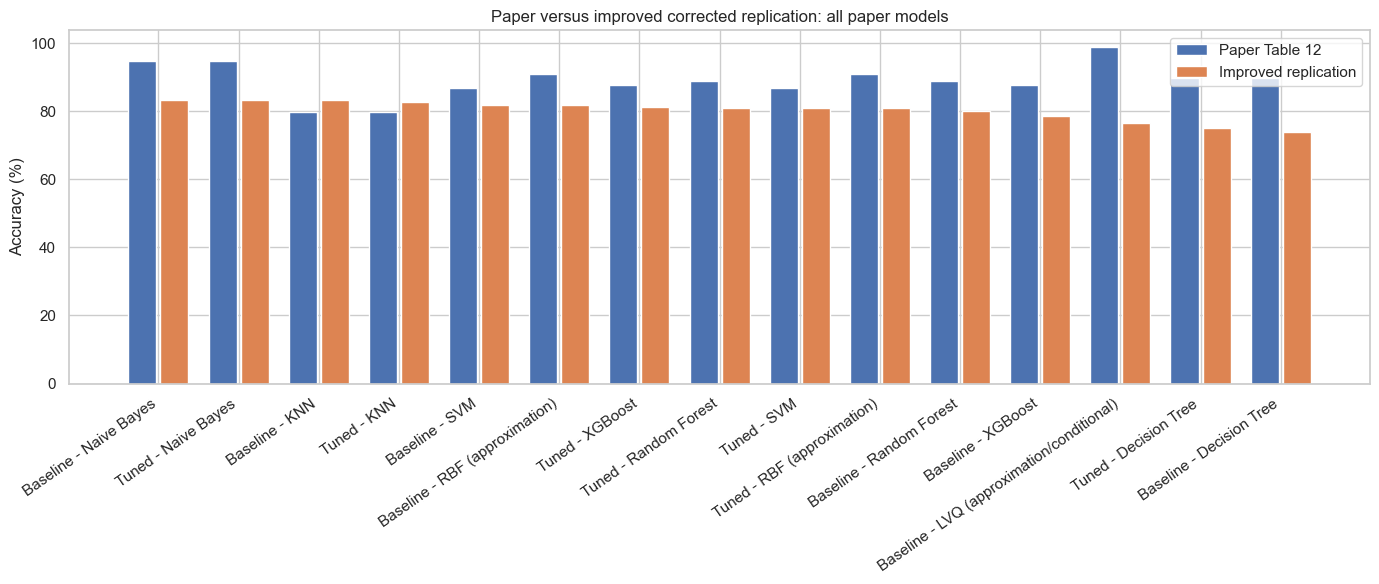

In [14]:
paper_accuracy = {"Random Forest": 88.78, "Decision Tree": 89.78, "SVM": 86.78, "XGBoost": 87.78, "RBF": 90.78, "KNN": 79.78, "LVQ": 98.78, "Naive Bayes": 94.78}
def paper_name(model_name):
    clean_name = model_name.replace("Baseline - ", "").replace("Tuned - ", "")
    if clean_name.startswith("RBF"):
        return "RBF"
    if clean_name.startswith("LVQ"):
        return "LVQ"
    return clean_name

paper_comparison = final_results[["Experiment", "Model", "Status", "Accuracy", "Balanced accuracy", "Sensitivity", "Specificity", "ROC-AUC", "PR-AUC"]].copy()
paper_comparison["Paper model"] = paper_comparison["Model"].map(paper_name)
paper_comparison["Accuracy (%)"] = paper_comparison["Accuracy"] * 100
paper_comparison["Paper Accuracy (%)"] = paper_comparison["Paper model"].map(paper_accuracy)
paper_comparison["Difference vs paper (point)"] = paper_comparison["Accuracy (%)"] - paper_comparison["Paper Accuracy (%)"]
display(paper_comparison.sort_values(["Paper model", "Experiment"]))

plot_data = paper_comparison.dropna(subset=["Paper Accuracy (%)", "Accuracy (%)"]).copy()
plot_data = plot_data.sort_values("Balanced accuracy", ascending=False).head(16)
plt.figure(figsize=(14, 6))
positions = np.arange(len(plot_data))
plt.bar(positions - 0.2, plot_data["Paper Accuracy (%)"], width=0.35, label="Paper Table 12")
plt.bar(positions + 0.2, plot_data["Accuracy (%)"], width=0.35, label="Improved replication")
plt.xticks(positions, plot_data["Model"], rotation=35, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Paper versus improved corrected replication: all paper models")
plt.legend()
plt.tight_layout()
plt.show()

## Kesimpulan eksperimen

- Corrected pipeline menjaga validitas evaluasi, tetapi tidak menjamin accuracy lebih tinggi dari paper.
- Tuning dinilai berhasil hanya jika meningkatkan performa cross-validation dan test set secara konsisten.
- Class imbalance pada dataset ini ringan; class-weight dan SMOTE diperlakukan sebagai eksperimen, bukan asumsi wajib.
- Model yang lebih baik dari paper harus dilaporkan bersama mean, standard deviation, metrik per kelas, dan keterbatasan perbedaan dataset.